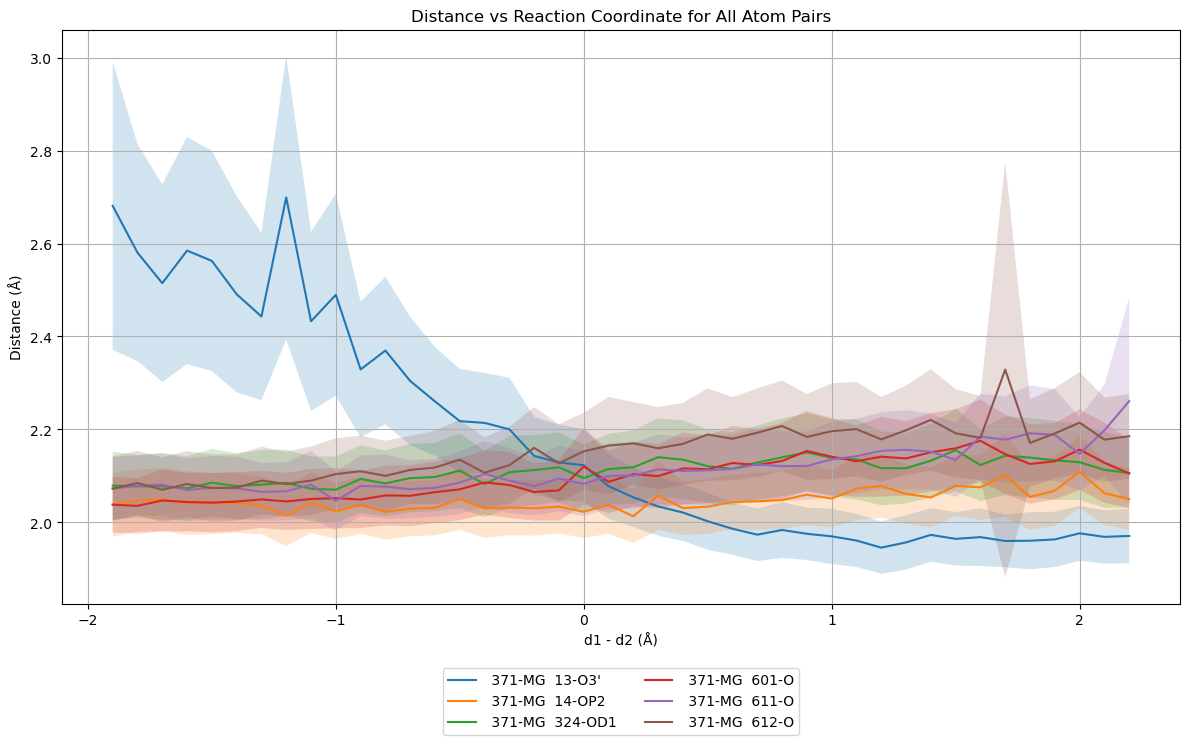

In [64]:
import pytraj as pt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os

# Check if distances_results.tsv exists
if os.path.exists("distances_results.tsv"):
    output_df = pd.read_csv("distances_results.tsv", sep='\t')
else:
    # Load coordination pairs
    coord_file = "get_coordination.tsv"
    df = pd.read_csv(coord_file, sep='\t')

    results = []

    # Automatically detect window directories with trajectory files
    base_dir = "../"
    all_dirs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()])

    # Map windows to reaction coordinates
    reaction_coords = np.round(np.arange(-1.90, 2.21, 0.10), 2)

    # Ensure number of directories matches expected reaction coordinates
    if len(all_dirs) != len(reaction_coords):
        raise ValueError("Mismatch between detected windows and reaction coordinate steps.")

    window_to_rc = dict(zip(all_dirs, reaction_coords))

    for window_name in all_dirs:
        window_path = os.path.join(base_dir, window_name)
        traj_files = sorted(glob(os.path.join(window_path, "step6.0*_equilibration.nc")))

        if not traj_files:
            continue

        parm = "../input/step3_pbcsetup.parm7"
        traj = pt.iterload(traj_files, parm)
        rc = window_to_rc[window_name]

        for mask in df['Atoms Pairs']:
            distances = pt.distance(traj, mask=mask)
            avg = np.mean(distances)
            std = np.std(distances)
            results.append([rc, mask, avg, std])

    # Save results
    output_df = pd.DataFrame(results, columns=["Reaction Coordinate", "Atoms Pairs", "Average Distance", "Std Dev"])
    output_df.to_csv("distances_results.tsv", sep='\t', index=False)

# Plot all atom pairs in one figure
plt.figure(figsize=(12, 8))
unique_pairs = output_df["Atoms Pairs"].unique()

for pair in unique_pairs:
    pair_df = output_df[output_df["Atoms Pairs"] == pair].sort_values("Reaction Coordinate")
    rc = pair_df["Reaction Coordinate"].values
    avg = pair_df["Average Distance"].values
    std = pair_df["Std Dev"].values

    label = pair.replace(":", " ").replace("@", "-")
    plt.plot(rc, avg, label=label)
    plt.fill_between(rc, avg - std, avg + std, alpha=0.2)

plt.xlabel("d1 - d2 (Å)")
plt.ylabel("Distance (Å)")
plt.title("Distance vs Reaction Coordinate for All Atom Pairs")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fontsize='medium', ncol=2)
plt.grid(True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("distances_plot_all_pairs.png")
plt.show()
plt.close()

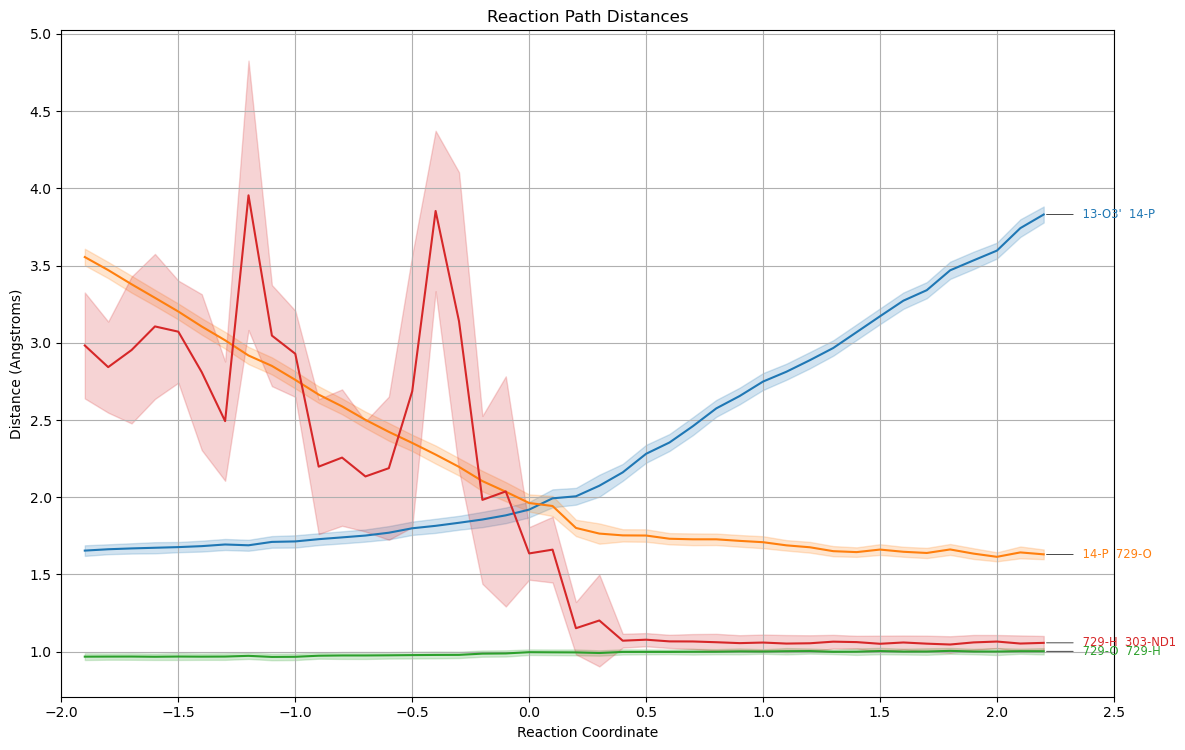

In [65]:
import pytraj as pt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os

# Compute and plot reaction path distances
rxn_file = "get_rxn.tsv"
rxn_df = pd.read_csv(rxn_file, sep='\t')

results = []

# Automatically detect window directories with trajectory files
base_dir = "../"
all_dirs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()])

# Map windows to reaction coordinates
reaction_coords = np.round(np.arange(-1.90, 2.21, 0.10), 2)

if len(all_dirs) != len(reaction_coords):
    raise ValueError("Mismatch between detected windows and reaction coordinate steps.")

window_to_rc = dict(zip(all_dirs, reaction_coords))

for window_name in all_dirs:
    window_path = os.path.join(base_dir, window_name)
    traj_files = sorted(glob(os.path.join(window_path, "step6.0*_equilibration.nc")))

    if not traj_files:
        continue

    parm = "../input/step3_pbcsetup.parm7"
    traj = pt.iterload(traj_files, parm)
    rc = window_to_rc[window_name]

    # Compute original distances
    dists = {}
    for mask in rxn_df['Atom Pairs']:
        dists[mask] = pt.distance(traj, mask=mask)

    # Merge pairs 3 & 4 into :729@O :729@H (minimum distance per frame)
    o_h = np.minimum(dists[":729@O :729@H1"], dists[":729@O :729@H2"])
    # Merge pairs 5 & 6 into :729@H :303@ND1 (minimum distance per frame)
    h_nd1 = np.minimum(dists[":729@H1 :303@ND1"], dists[":729@H2 :303@ND1"])

    merged = {
        ":13@O3' :14@P": dists[":13@O3' :14@P"],
        ":14@P :729@O": dists[":14@P :729@O"],
        ":729@O :729@H": o_h,
        ":729@H :303@ND1": h_nd1
    }

    for pair, values in merged.items():
        avg = np.mean(values)
        std = np.std(values)
        results.append([rc, pair, avg, std])

# Save reaction distances
rxn_output = pd.DataFrame(results, columns=["Reaction Coordinate", "Atom Pairs", "Average Distance", "Std Dev"])
rxn_output.to_csv("reaction_distances.tsv", sep='\t', index=False)

# Plot reaction path distances
fig, ax = plt.subplots(figsize=(12, 8))
unique_pairs = rxn_output["Atom Pairs"].unique()
ax.set_xlim(-2.0, 2.5)

for pair in unique_pairs:
    pair_df = rxn_output[rxn_output["Atom Pairs"] == pair].sort_values("Reaction Coordinate")
    rc = pair_df["Reaction Coordinate"].values
    avg = pair_df["Average Distance"].values
    std = pair_df["Std Dev"].values

    label = pair.replace(":", " ").replace("@", "-")
    line, = ax.plot(rc, avg)
    ax.fill_between(rc, avg - std, avg + std, alpha=0.2, color=line.get_color())
    ax.annotate(label, xy=(rc[-1], avg[-1]), xytext=(rc[-1] + 0.15, avg[-1]),
                textcoords='data', color=line.get_color(), fontsize='small', va='center', arrowprops=dict(arrowstyle='-', lw=0.5))

ax.set_xlabel("Reaction Coordinate")
ax.set_ylabel("Distance (Angstroms)")
ax.set_title("Reaction Path Distances")
ax.grid(True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("reaction_plot_all_pairs.png")
plt.show()
plt.close()

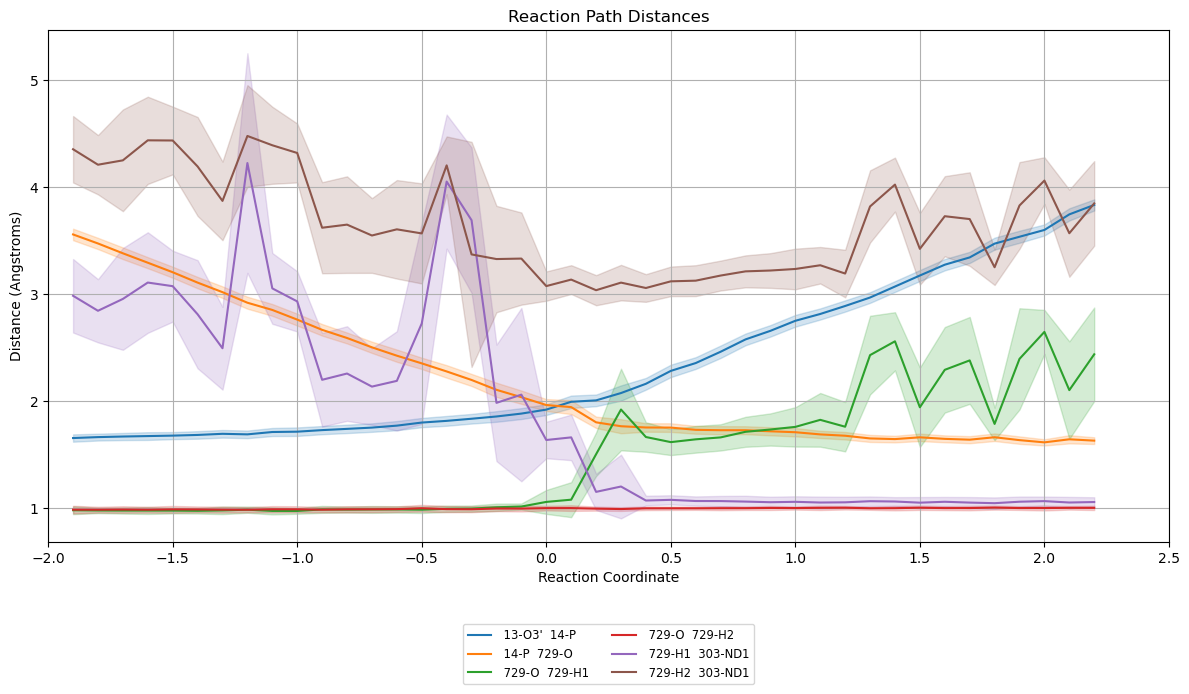

In [70]:
import pytraj as pt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os

# Compute and plot reaction path distances
rxn_file = "get_rxn.tsv"
rxn_df = pd.read_csv(rxn_file, sep='\t')

results = []
raw_data = []

# Automatically detect window directories with trajectory files
base_dir = "../"
all_dirs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()])

# Map windows to reaction coordinates
reaction_coords = np.round(np.arange(-1.90, 2.21, 0.10), 2)

if len(all_dirs) != len(reaction_coords):
    raise ValueError("Mismatch between detected windows and reaction coordinate steps.")

window_to_rc = dict(zip(all_dirs, reaction_coords))

for window_name in all_dirs:
    window_path = os.path.join(base_dir, window_name)
    traj_files = sorted(glob(os.path.join(window_path, "step6.0*_equilibration.nc")))

    if not traj_files:
        continue

    parm = "../input/step3_pbcsetup.parm7"
    traj = pt.iterload(traj_files, parm)
    rc = window_to_rc[window_name]

    # Compute original distances
    dists = {}
    for mask in rxn_df['Atom Pairs']:
        dists[mask] = pt.distance(traj, mask=mask)

    for pair, values in dists.items():
        avg = np.mean(values)
        std = np.std(values)
        results.append([rc, pair, avg, std])
        for v in values:
            raw_data.append([rc, pair, v])

# Save reaction distances summary
rxn_output = pd.DataFrame(results, columns=["Reaction Coordinate", "Atom Pairs", "Average Distance", "Std Dev"])
rxn_output.to_csv("reaction_distances.tsv", sep='\t', index=False)

# Save raw reaction distance data
raw_df = pd.DataFrame(raw_data, columns=["Reaction Coordinate", "Atom Pairs", "Distance"])
raw_df.to_csv("reaction_raw_distances.tsv", sep='\t', index=False)

# Plot reaction path distances
fig, ax = plt.subplots(figsize=(12, 8))
unique_pairs = rxn_output["Atom Pairs"].unique()
ax.set_xlim(-2.0, 2.5)

lines = []
labels = []

for pair in unique_pairs:
    pair_df = rxn_output[rxn_output["Atom Pairs"] == pair].sort_values("Reaction Coordinate")
    rc = pair_df["Reaction Coordinate"].values
    avg = pair_df["Average Distance"].values
    std = pair_df["Std Dev"].values

    label = pair.replace(":", " ").replace("@", "-")
    line, = ax.plot(rc, avg, label=label)
    ax.fill_between(rc, avg - std, avg + std, alpha=0.2, color=line.get_color())
    lines.append(line)
    labels.append(label)

ax.set_xlabel("Reaction Coordinate")
ax.set_ylabel("Distance (Angstroms)")
ax.set_title("Reaction Path Distances")
ax.grid(True)
ax.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize='small', ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("reaction_plot_all_pairs.png")
plt.show()
plt.close()

In [73]:
import pytraj as pt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os

# === Shared Setup ===
parm = "../input/step3_pbcsetup.parm7"
base_dir = "../"
reaction_coords = np.round(np.arange(-1.90, 2.21, 0.10), 2)
all_dirs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()])
if len(all_dirs) != len(reaction_coords):
    raise ValueError("Mismatch between detected windows and reaction coordinate steps.")
window_to_rc = dict(zip(all_dirs, reaction_coords))

# === Coordination Analysis ===
coord_file = "get_coordination.tsv"
coord_df = pd.read_csv(coord_file, sep='\t')
coord_results = []

for window_name in all_dirs:
    window_path = os.path.join(base_dir, window_name)
    traj_files = sorted(glob(os.path.join(window_path, "step6.0*_equilibration.nc")))
    if not traj_files:
        continue
    traj = pt.iterload(traj_files, parm)
    rc = window_to_rc[window_name]
    for mask in coord_df['Atoms Pairs']:
        distances = pt.distance(traj, mask=mask)
        avg = np.mean(distances)
        std = np.std(distances)
        coord_results.append([rc, mask, avg, std])

coord_df_out = pd.DataFrame(coord_results, columns=["Reaction Coordinate", "Atoms Pairs", "Average Distance", "Std Dev"])
coord_df_out.to_csv("distances_results.tsv", sep='\t', index=False)

# === Reaction Path Analysis ===
rxn_file = "get_rxn.tsv"
rxn_df = pd.read_csv(rxn_file, sep='\t')
rxn_results = []
rxn_raw_data = []

for window_name in all_dirs:
    window_path = os.path.join(base_dir, window_name)
    traj_files = sorted(glob(os.path.join(window_path, "step6.0*_equilibration.nc")))
    if not traj_files:
        continue
    traj = pt.iterload(traj_files, parm)
    rc = window_to_rc[window_name]
    dists = {mask: pt.distance(traj, mask=mask) for mask in rxn_df['Atom Pairs']}
    for pair, values in dists.items():
        avg = np.mean(values)
        std = np.std(values)
        rxn_results.append([rc, pair, avg, std])
        for v in values:
            rxn_raw_data.append([rc, pair, v])

rxn_df_out = pd.DataFrame(rxn_results, columns=["Reaction Coordinate", "Atom Pairs", "Average Distance", "Std Dev"])
rxn_df_out.to_csv("reaction_distances.tsv", sep='\t', index=False)
raw_df = pd.DataFrame(rxn_raw_data, columns=["Reaction Coordinate", "Atom Pairs", "Distance"])
raw_df.to_csv("reaction_raw_distances.tsv", sep='\t', index=False)

# === Plot Coordination Distances ===
fig1, ax1 = plt.subplots(figsize=(12, 8))
unq_pairs = coord_df_out["Atoms Pairs"].unique()
ax1.set_xlim(-2.0, 2.5)
for pair in unq_pairs:
    df = coord_df_out[coord_df_out["Atoms Pairs"] == pair].sort_values("Reaction Coordinate")
    rc = df["Reaction Coordinate"].values
    avg = df["Average Distance"].values
    std = df["Std Dev"].values
    label = pair.replace(":", " ").replace("@", "-")
    line, = ax1.plot(rc, avg, label=label)
    ax1.fill_between(rc, avg - std, avg + std, alpha=0.2, color=line.get_color())
ax1.set_xlabel("Reaction Coordinate")
ax1.set_ylabel("Distance (Angstroms)")
ax1.set_title("Coordination Distances")
ax1.grid(True)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize='small', ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("coordination_plot_all_pairs.png")
plt.show()
plt.close()

# === Plot Reaction Distances ===
fig2, ax2 = plt.subplots(figsize=(12, 8))
unq_pairs = rxn_df_out["Atom Pairs"].unique()
ax2.set_xlim(-2.0, 2.5)
for pair in unq_pairs:
    df = rxn_df_out[rxn_df_out["Atom Pairs"] == pair].sort_values("Reaction Coordinate")
    rc = df["Reaction Coordinate"].values
    avg = df["Average Distance"].values
    std = df["Std Dev"].values
    label = pair.replace(":", " ").replace("@", "-")
    line, = ax2.plot(rc, avg, label=label)
    ax2.fill_between(rc, avg - std, avg + std, alpha=0.2, color=line.get_color())
ax2.set_xlabel("Reaction Coordinate")
ax2.set_ylabel("Distance (Angstroms)")
ax2.set_title("Reaction Path Distances")
ax2.grid(True)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize='small', ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("reaction_plot_all_pairs.png")
plt.show()
plt.close()

KeyboardInterrupt: 

In [74]:
import pytraj as pt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from multiprocessing import Pool
import os

# === Config ===
parm = "../input/step3_pbcsetup.parm7"
base_dir = "../"
reaction_coords = np.round(np.arange(-1.90, 2.21, 0.10), 2)

# === Validate and Map Windows ===
all_dirs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()])
if len(all_dirs) != len(reaction_coords):
    raise ValueError("Mismatch between detected windows and reaction coordinate steps.")
window_to_rc = dict(zip(all_dirs, reaction_coords))

# === Load TSV Inputs ===
coord_df = pd.read_csv("get_coordination.tsv", sep='\t')
rxn_df = pd.read_csv("get_rxn.tsv", sep='\t')

# === Core Distance Computation Function ===
def process_window(window_name):
    rc = window_to_rc[window_name]
    window_path = os.path.join(base_dir, window_name)
    traj_files = sorted(glob(os.path.join(window_path, "step6.0*_equilibration.nc")))
    if not traj_files:
        return [], [], []

    traj = pt.iterload(traj_files, parm)

    # Coordination
    coord_data = []
    for mask in coord_df['Atoms Pairs']:
        distances = pt.distance(traj, mask=mask)
        coord_data.append([rc, mask, np.mean(distances), np.std(distances)])

    # Reaction Path
    rxn_data = []
    rxn_raw = []
    for mask in rxn_df['Atom Pairs']:
        distances = pt.distance(traj, mask=mask)
        rxn_data.append([rc, mask, np.mean(distances), np.std(distances)])
        rxn_raw.extend([[rc, mask, d] for d in distances])

    return coord_data, rxn_data, rxn_raw

# === Run in Parallel (2 Processes) ===
with Pool(processes=2) as pool:
    results = pool.map(process_window, all_dirs)

# === Merge Results ===
coord_results = [row for result in results for row in result[0]]
rxn_results = [row for result in results for row in result[1]]
rxn_raw_data = [row for result in results for row in result[2]]

# === Export TSVs ===
coord_df_out = pd.DataFrame(coord_results, columns=["Reaction Coordinate", "Atoms Pairs", "Average Distance", "Std Dev"])
coord_df_out.to_csv("distances_results.tsv", sep='\t', index=False)

rxn_df_out = pd.DataFrame(rxn_results, columns=["Reaction Coordinate", "Atom Pairs", "Average Distance", "Std Dev"])
rxn_df_out.to_csv("reaction_distances.tsv", sep='\t', index=False)

raw_df = pd.DataFrame(rxn_raw_data, columns=["Reaction Coordinate", "Atom Pairs", "Distance"])
raw_df.to_csv("reaction_raw_distances.tsv", sep='\t', index=False)

# === Plotting Function ===
def plot_distances(df, title, file_name, colname="Atoms Pairs"):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(-2.0, 2.5)
    unique_pairs = df[colname].unique()
    lines, labels = [], []

    for pair in unique_pairs:
        subset = df[df[colname] == pair].sort_values("Reaction Coordinate")
        rc = subset["Reaction Coordinate"].values
        avg = subset["Average Distance"].values
        std = subset["Std Dev"].values
        label = pair.replace(":", " ").replace("@", "-")
        line, = ax.plot(rc, avg, label=label)
        ax.fill_between(rc, avg - std, avg + std, alpha=0.2, color=line.get_color())
        lines.append(line)
        labels.append(label)

    ax.set_xlabel("Reaction Coordinate")
    ax.set_ylabel("Distance (Angstroms)")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize='small', ncol=2, frameon=True)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.savefig(file_name)
    plt.close()

# === Generate Plots ===
plot_distances(coord_df_out, "Coordination Distances", "coordination_plot_all_pairs.png")
plot_distances(rxn_df_out, "Reaction Path Distances", "reaction_plot_all_pairs.png", colname="Atom Pairs")